### Day 1

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("../data/cs-training.csv", index_col=0)

rename = {
 "SeriousDlqin2yrs":"default", "RevolvingUtilizationOfUnsecuredLines":"utilization",
 "age":"age", "NumberOfTime30-59DaysPastDueNotWorse":"late_30_59",
 "DebtRatio":"debt_ratio", "MonthlyIncome":"income",
 "NumberOfOpenCreditLinesAndLoans":"open_lines", "NumberOfTimes90DaysLate":"late_90",
 "NumberRealEstateLoansOrLines":"real_estate_loans",
 "NumberOfTime60-89DaysPastDueNotWorse":"late_60_89", "NumberOfDependents":"dependents"}
df = df.rename(columns=rename)

In [3]:
df.shape

(150000, 11)

In [6]:
df.head()

,default,utilization,age,late_30_59,debt_ratio,income,open_lines,late_90,real_estate_loans,late_60_89,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   default            150000 non-null  int64  
 1   utilization        150000 non-null  float64
 2   age                150000 non-null  int64  
 3   late_30_59         150000 non-null  int64  
 4   debt_ratio         150000 non-null  float64
 5   income             120269 non-null  float64
 6   open_lines         150000 non-null  int64  
 7   late_90            150000 non-null  int64  
 8   real_estate_loans  150000 non-null  int64  
 9   late_60_89         150000 non-null  int64  
 10  dependents         146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
default,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
utilization,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
late_30_59,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
debt_ratio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
income,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
open_lines,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
late_90,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
real_estate_loans,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
late_60_89,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [12]:
df.isna().sum()

default                  0
utilization              0
age                      0
late_30_59               0
debt_ratio               0
income               29731
open_lines               0
late_90                  0
real_estate_loans        0
late_60_89               0
dependents            3924
dtype: int64

In [13]:
df["default"].value_counts(normalize="True")

default
0    0.93316
1    0.06684
Name: proportion, dtype: float64

**What does each column means?**  
- **default**: Indicates whether a borrower experianced a serious delinquency within next 2 year
- **utilization**: Ratio of total balance on credit and maximum limit of credit card
- **debt_ratio**: Monthly debt payments, alimony, living cost divided by gross monthly income
- **age**: age of borrower
- **income**: Borrowers gross income
- **dependence**: The number of family members who depend on the borrower financially
- **late_30_59**: How many times borrower has been 30-59 days late on payments
- **late_60_89**: How many times borrower has been 60-89 days late on payments
- **late_90**: How many times borrower has been 90+ days late on payments (serious delinquency)
- **open_lines**: no. of open credit accounts (like credit cards) and loans (like auto loans)
- **real_estate_loans**: The number of mortgage and home equity loans or lines of credit




**What is the target, and what fraction of peoples default?**  

**Target**: The target here is default which indicates serious delinquency (defaults are usually quite rare and can have problems)  
**Fraction of defaults**: The Fraction of default is 6.7%



**Which columns have missing values, and how many?**  

Income and Dependence  
- Income: 29731
- Dependence: 3924



**Why would 93% accuracy be useless here?**

Because Default in dataset indicated a redflag, class imbalance is present (93% of non defaulters and 7 percent of defaulters) this highly imbalanced dataset can make ML model cheat and It will guess everyone a non defaulter making a model 93% accurate.  
We have to handle this imbalance.



### Day 2

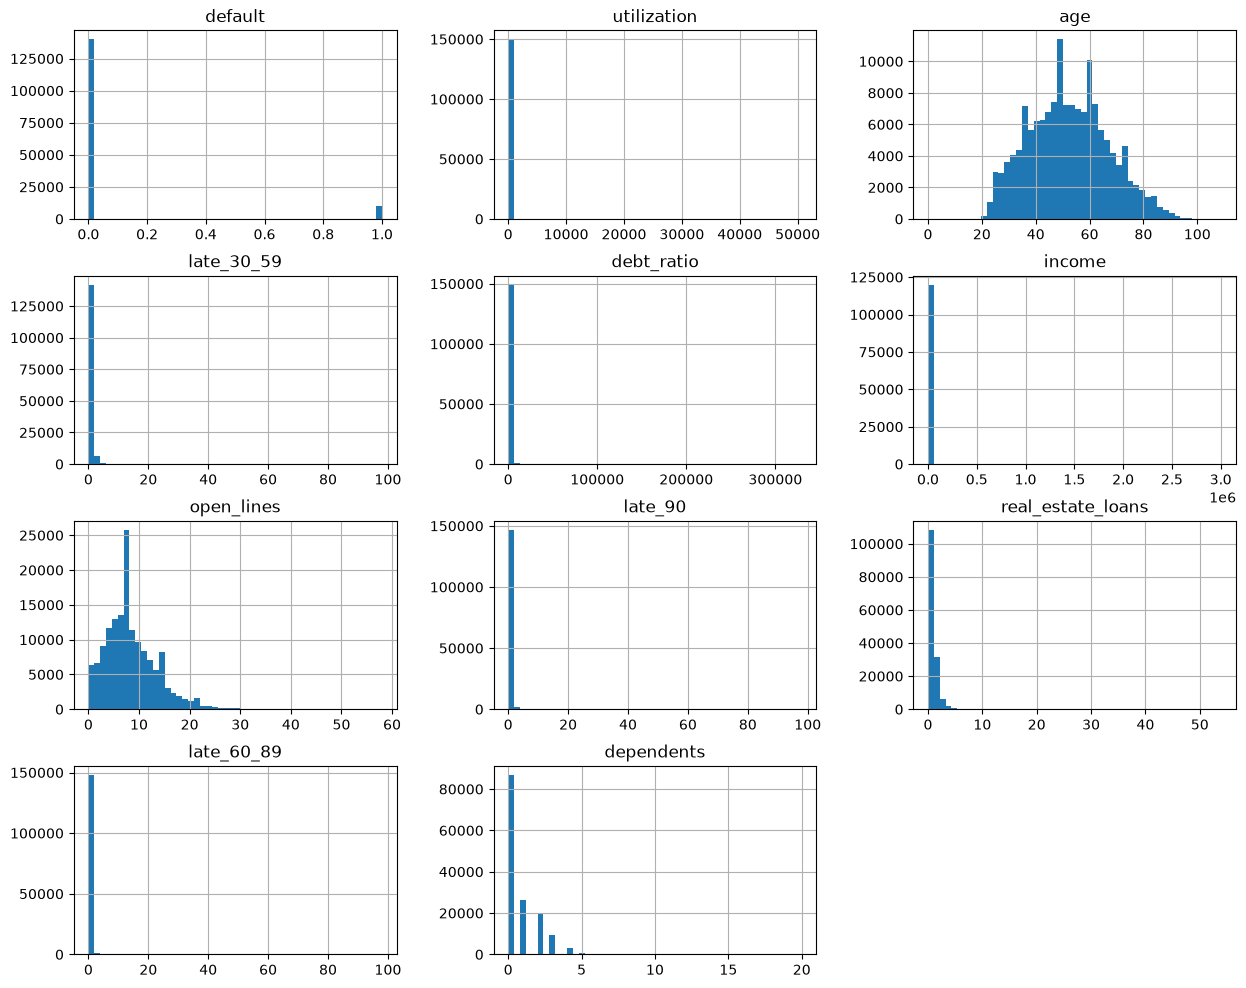

In [7]:
df.hist(bins=50, figsize=(15,12))
plt.savefig("../assets/eda_histogram01.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
df.groupby("default").mean().T

default,0,1
utilization,6.168855,4.367282
age,52.751375,45.926591
late_30_59,0.280109,2.388490
debt_ratio,357.151168,295.121066
income,6747.837774,5630.826493
open_lines,8.493620,7.882306
late_90,0.135225,2.091362
real_estate_loans,1.020368,0.988530
late_60_89,0.126666,1.828047
dependents,0.743417,0.948208


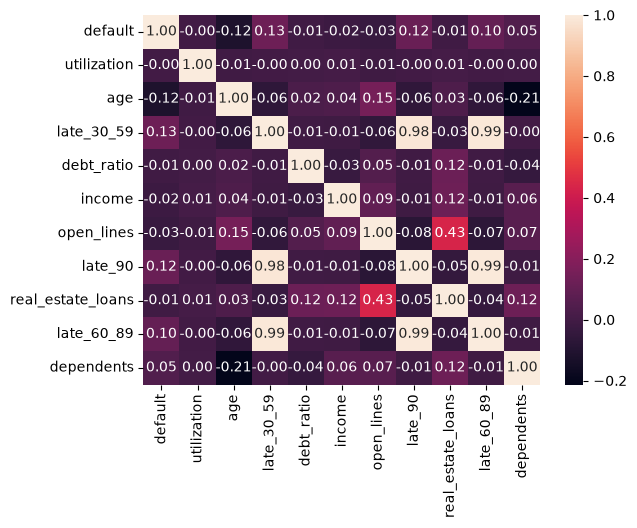

In [6]:
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.savefig("../assets/eda_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

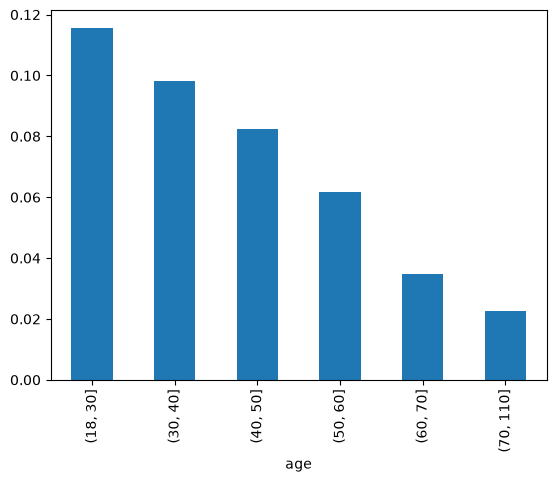

In [8]:
df.groupby(pd.cut(df["age"], [18,30,40,50,60,70,110]))["default"].mean().plot(kind = "bar")
plt.savefig("../assets/eda_histogram02.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
## AGE IS ZERO OR BELOW 18
below_18_age_rows = df[df["age"] < 18]
print(below_18_age_rows)

       default  utilization  age  late_30_59  debt_ratio  income  open_lines  \
65696        0          1.0    0           1    0.436927  6000.0           6   

       late_90  real_estate_loans  late_60_89  dependents  
65696        0                  2           0         2.0  


In [ ]:
## CHECKING WHAT FRACTION OF 96,98 IN LATE_* IS DEFAULT
# rows_above_15_in_late_1 = df[df["late_30_59"] > 15]
# print(rows_above_15_in_late_1)
late_cols = ["late_30_59", "late_60_89", "late_90"]
placeholder_mask = df[late_cols].isin([96,98]).any(axis=1)
print(placeholder_mask)
placeholder_default_rate = df.loc[placeholder_mask, "default"].mean()
print(f"Default rate for placeholder rows: {placeholder_default_rate:.2%}")



1         False
2         False
3         False
4         False
5         False
          ...  
149996    False
149997    False
149998    False
149999    False
150000    False
Length: 150000, dtype: bool
Default rate for placeholder rows: 54.65%


IS UTILIZATION AND DEBT RATIO HAVE ABSURD VALUES, DISTRIBUTION OF INCOME IS HEAVILY SKEWED

In [ ]:

target_cols = ["utilization", "debt_ratio", "income"]

# Generate summary stats including the 50th (median), 95th, 99th, and 99.9th percentiles
distribution_summary = df[target_cols].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
)
print(distribution_summary)


         utilization     debt_ratio        income
count  150000.000000  150000.000000  1.202690e+05
mean        6.048438     353.005076  6.670221e+03
std       249.755371    2037.818523  1.438467e+04
min         0.000000       0.000000  0.000000e+00
25%         0.029867       0.175074  3.400000e+03
50%         0.154181       0.366508  5.400000e+03
75%         0.559046       0.868254  8.249000e+03
95%         1.000000    2449.000000  1.458760e+04
99%         1.092956    4979.040000  2.500000e+04
99.9%    1571.006000   10613.074000  7.839575e+04
max     50708.000000  329664.000000  3.008750e+06


In [ ]:
## Prove Utilization absurd maximums (> 1)
util_above_1 = (df["utilization"] > 1).mean()
util_max = df["utilization"].max()
print(
    f"Utilization Max: {util_max:,.2f} | Rows > 1: {util_above_1:.2%}"
)

# 2. Prove Debt Ratio absurd maximums (> 1 or > 10)
debt_above_10 = (df["debt_ratio"] > 10).mean()
debt_max = df["debt_ratio"].max()
print(
    f"Debt Ratio Max: {debt_max:,.2f} | Rows > 10: {debt_above_10:.2%}"
)


Utilization Max: 50,708.00 | Rows > 1: 2.21%
Debt Ratio Max: 329,664.00 | Rows > 10: 19.25%


In [33]:
# Compute Fisher-Pearson skewness coefficient
income_skew = df["income"].skew()
print(f"Monthly Income Skewness: {income_skew:.2f}")

Monthly Income Skewness: 114.04


### Cleaning Decisions ###

- drop rows < 18
- Flag 96/98 rows and replace them with NaN
- clip utilization and debt_ration at there 99th and 95% respectively
- Median-impute income and dependents later, inside the pipeline
- 3 late columns are nearly identical to each other

### EDA Insights ###

- Default rate falls as age rises
- Late-payment counts are the strongest signal
- utlization and debt are strong markers but the correlation of the with default is near 0
- open_lines ↔ real_estate_loans: 0.43 — a moderate positive correlation. Not alarming, but worth noting — makes sense, since real estate loans are a type of open credit line.
- income, debt_ratio, dependents, and open_lines all show negligible linear correlation with each other and with default